# 03_2_Rating_Fraud_Analysis: 별점 기반 사기 리뷰 특성 분석

**※ 분석 방향성**: 별점을 별도의 노드로 분리하지 않고, EDA 결과를 유저 및 상점 노드의 **파생 변수(Feature)**로 녹여내기 위한 분석입니다.

이 노트북은 리뷰의 **'별점(Rating)'** 정보를 중심으로 사기 리뷰(Fraud)의 패턴을 정량적으로 분석하고, 이를 GNN 모델의 피처로 연결하기 위한 인사이트를 도출합니다.

### 분석 핵심 포인트
1. **별점별 사기 비율**: 1점(Pollute) vs 5점(Push) 전략의 실태 파악
2. **평균 평점 이탈도 (Rating Deviation)**: 대중의 의견과 얼마나 괴리가 있는가?
3. **유저 행동 엔트로피**: 사기 유저는 특정 별점만 고집하는가?
4. **별점-텍스트 모순 지수 (Dissonance)**: 별점과 리뷰 내용이 일치하는가? -> 삭제함(의미없어서)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from common_utils import load_data, setup_plotting

# 시각화 설정
setup_plotting()

Plotting setup complete for Windows (Font: Malgun Gothic)


## 1. 데이터 로드
01_Data_Preprocessing에서 생성한 샘플링 데이터를 사용합니다.

In [2]:
df = load_data("yelpzip_sampled.parquet")
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (50950, 8)


,user_id,prod_id,rating,label,date,text,tag,ym
0,5798,9,1.0,1,2014-12-18,I would give this place a 0 . I drove an hour ...,fake,2014-12
1,5799,9,1.0,1,2014-12-09,So me giving one star to Geno's steaks seems l...,fake,2014-12
2,5800,9,1.0,1,2014-11-12,"After reading all of the negative reviews, I r...",fake,2014-11
3,5801,9,1.0,1,2014-11-12,Their cheesestake had absolutely no taste WHAT...,fake,2014-11
4,5802,9,1.0,1,2014-11-11,"Was very disappointed, I have seen more meat o...",fake,2014-11


## 2. 별점별 사기 분포 분석 (Rating-based Fraud Ratio)
가설: 1점 리뷰는 전체 수량은 적지만 사기 비율은 압도적으로 높을 것이다 (Pollute 전략).

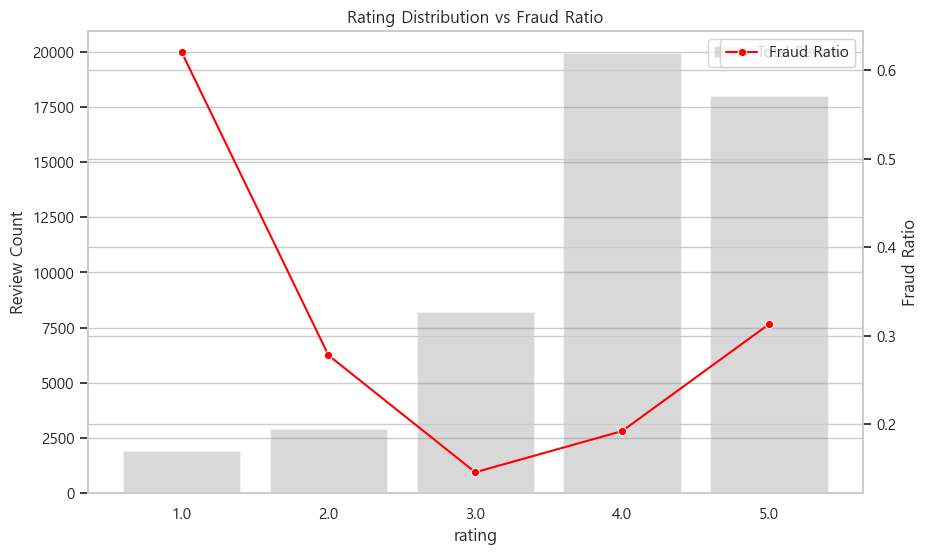

,rating,total_count,fraud_count,fraud_ratio
0,1.0,1922,1192,0.620187
1,2.0,2896,805,0.277970
2,3.0,8211,1198,0.145902
3,4.0,19928,3833,0.192342
4,5.0,17993,5631,0.312955


In [3]:
# 별점별 리뷰 수 및 사기 리뷰 비율 계산
rating_stats = df.groupby('rating').agg(
    total_count=('label', 'count'),
    fraud_count=('label', 'sum')
).reset_index()

rating_stats['fraud_ratio'] = rating_stats['fraud_count'] / rating_stats['total_count']

# 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=rating_stats, x='rating', y='total_count', alpha=0.3, ax=ax1, color='gray', label='Total Reviews')
ax2 = ax1.twinx()
sns.lineplot(data=rating_stats, x=rating_stats.index, y='fraud_ratio', marker='o', color='red', ax=ax2, label='Fraud Ratio')

ax1.set_ylabel('Review Count')
ax2.set_ylabel('Fraud Ratio')
plt.title('Rating Distribution vs Fraud Ratio')
plt.show()

display(rating_stats)

## 3. 평균 평점 이탈도 (Rating Deviation)
식당의 평균 평점과 개별 리뷰 별점 간의 차이를 계산합니다. 사기 리뷰일수록 이탈도가 클 가능성이 높습니다.

시간 분리 기준일: 2014-06-28  (사기 비율 차이: 0.0467)
Train 사기 비율: 0.235 | Test 사기 비율: 0.282


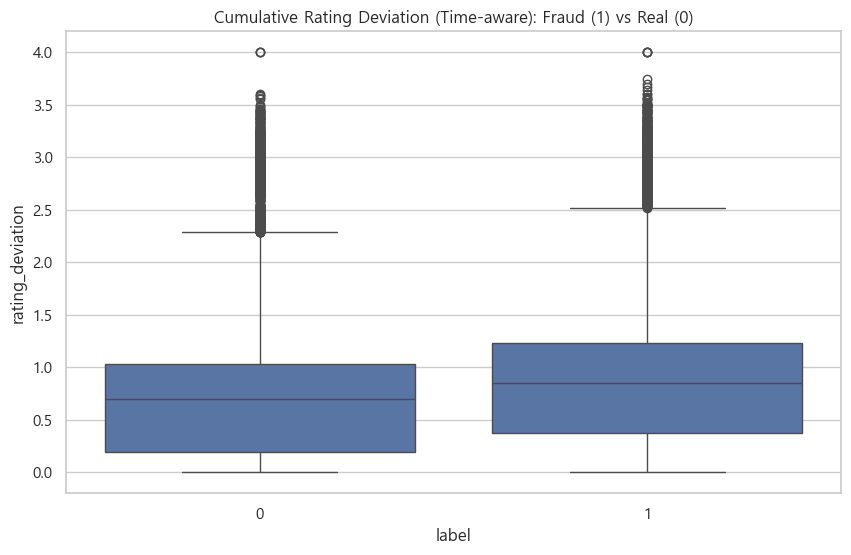

Applied Train-only Global Mean: 3.97

Cumulative Rating Deviation Stats by Label:
         count      mean       std  min       25%       50%       75%  max
label                                                                     
0      38291.0  0.710637  0.592933  0.0  0.190476  0.695146  1.028571  4.0
1      12659.0  0.962797  0.768295  0.0  0.375801  0.854015  1.232781  4.0


In [4]:
from sklearn.model_selection import train_test_split

# 시간 기준 분리 (Option B: 사기 비율 균형 cutoff 탐색)
# 분리를 먼저 수행해야 이후 global_mean이 train 기준으로만 계산됨 — 누수 방지
df = df.sort_values('date').reset_index(drop=True)
N = len(df)
labels_arr = df['label'].values

best_idx, best_diff = None, float('inf')
for cutoff in range(int(N * 0.72), int(N * 0.88)):
    tr_ratio = labels_arr[:cutoff].mean()
    te_ratio = labels_arr[cutoff:].mean()
    diff = abs(tr_ratio - te_ratio)
    if diff < best_diff:
        best_diff, best_idx = diff, cutoff

idx_trainval = np.arange(best_idx)
idx_test     = np.arange(best_idx, N)
idx_train, _ = train_test_split(
    idx_trainval, test_size=0.20, random_state=42,
    stratify=labels_arr[idx_trainval]
)
df['_is_train'] = False
df.loc[idx_train, '_is_train'] = True

cutoff_date = df.iloc[best_idx]['date'].date()
print(f"시간 분리 기준일: {cutoff_date}  (사기 비율 차이: {best_diff:.4f})")
print(f"Train 사기 비율: {labels_arr[idx_train].mean():.3f} | "
      f"Test 사기 비율: {labels_arr[idx_test].mean():.3f}")

# global_mean: train 행의 평점만 사용 — 누수 방지
global_mean = df.loc[df['_is_train'], 'rating'].mean()

# prod_id + date 순 정렬 (그룹 내 누적 평균 계산 필수)
df = df.sort_values(['prod_id', 'date']).reset_index(drop=True)

# 그룹별 누적 리뷰 개수 계산 (콜드 스타트 플래그용)
df['prod_review_count'] = df.groupby('prod_id').cumcount() + 1

# 그룹별 누적 평균 계산 (Expanding Mean)
# shift(1): 현재 리뷰 작성 직전까지의 평균만 반영
df['prod_cumulative_avg'] = df.groupby('prod_id')['rating'].transform(
    lambda x: x.expanding().mean().shift(1)
)

# 첫 리뷰 처리: train 기준 global_mean으로 대체
df['prod_cumulative_avg'] = df['prod_cumulative_avg'].fillna(global_mean)

# 콜드 스타트 지시 변수 (누적 리뷰 수 5개 이하)
df['is_cold_start'] = np.where(df['prod_review_count'] <= 5, 1, 0)

# 누적 이탈도 계산
df['rating_deviation'] = (df['rating'] - df['prod_cumulative_avg']).abs()

df = df.drop(columns=['prod_review_count'])

# 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='label', y='rating_deviation')
plt.title('Cumulative Rating Deviation (Time-aware): Fraud (1) vs Real (0)')
plt.show()

print(f"Applied Train-only Global Mean: {global_mean:.2f}")
print("\nCumulative Rating Deviation Stats by Label:")
print(df.groupby('label')['rating_deviation'].describe())

## 4. 유저 행동 엔트로피 (Rating Entropy)
특정 유저가 얼마나 일관되게(혹은 편향되게) 별점을 주는지 확인합니다.

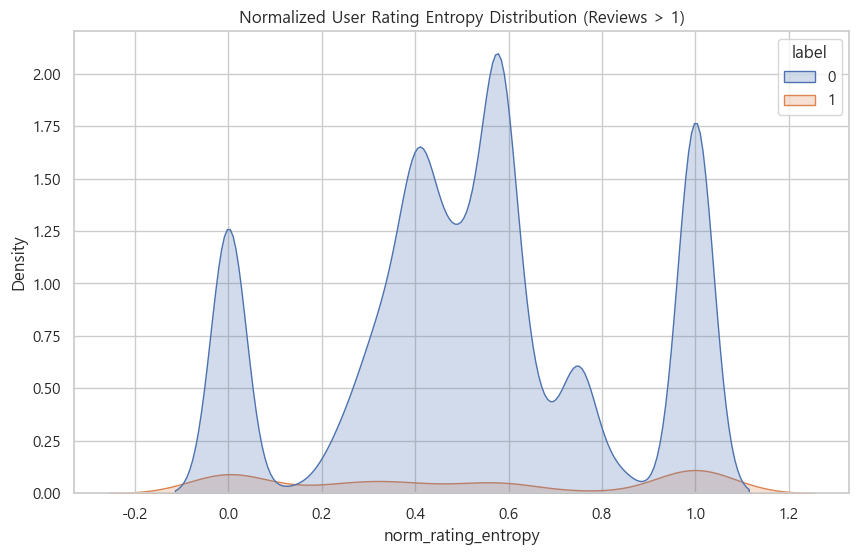

In [5]:
from scipy.stats import entropy

def calculate_normalized_entropy(x):
    n = len(x)
    if n <= 1:
        return np.nan
    counts = x.value_counts(normalize=True).values
    return entropy(counts) / np.log(n)

# 유저 엔트로피: train 행만으로 계산 — 누수 방지
# test 유저의 미래 리뷰 패턴이 훈련 피처에 반영되는 것을 차단
train_df = df[df['_is_train']]
user_entropy = train_df.groupby('user_id')['rating'].agg(calculate_normalized_entropy).rename('norm_rating_entropy')
df = df.merge(user_entropy, on='user_id', how='left')

# is_single_review: train 기준 리뷰 1개인 유저 (NaN = train에 1개 이하)
df['is_single_review'] = df['norm_rating_entropy'].isna().astype(int)
df['norm_rating_entropy'] = df['norm_rating_entropy'].fillna(0.5)

# 엔트로피 분포 확인 (리뷰 1개 유저 제외)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['is_single_review'] == 0], x='norm_rating_entropy', hue='label', fill=True)
plt.title('Normalized User Rating Entropy Distribution (Reviews > 1)')
plt.show()

## 6. 결론 및 GNN 피처 제안

분석 결과, 다음과 같은 피처들이 GNN 모델의 성능 향상에 기여할 것으로 기대됩니다:

1. **`rating_onehot`**: 별점을 범주형 피처로 처리하여 Push/Pollute 특성 반영
2. **`rating_deviation`**: 식당 평균과의 괴리를 나타내는 강력한 사기 지표
3. **`norm_rating_entropy`**: 유저의 정규화된 별점 부여 패턴 (활동량 편향 제거)
4. **`is_dissonant`**: 텍스트 내용과 별점이 일치하지 않는 노드 플래그
5. **`is_cold_start`, `is_single_review`**: 데이터 부족 구간을 나타내는 지시 변수

이 피처들을 `features_rating.csv`로 저장하여 향후 모델링에 활용하겠습니다.

In [ ]:
from common_utils import save_features

# _is_train 내부 마커 제거 후 저장
df_save = df.drop(columns=['_is_train'], errors='ignore')
final_features = df_save[['user_id', 'prod_id', 'rating_deviation', 'norm_rating_entropy', 'is_cold_start', 'is_single_review']]
save_features(df_save, final_features, "rating")

Feature 'rating' saved to features_rating.csv


: 